# Multivariate Regression Covid

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [3]:
df = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [4]:
df['country'].unique()

array(['Chile', 'Colombia', 'Italy', 'Mexico', 'US'], dtype=object)

In [5]:
import json
from pathlib import Path

# path to the JSON file
json_path = Path("..") / "Data" / "gold" / "features_dict.json"

# read it into a Python dict
with json_path.open("r", encoding="utf‑8") as f:
    features_dict = json.load(f)

# quick sanity check
print(f"Loaded {len(features_dict)} keys from features_dict.json")

Loaded 2 keys from features_dict.json


In [6]:
selected_features_covid = features_dict['covid_col']

In [7]:
selected_features_covid

['new_cases', 'google_symptom', 'o3', 'pop_vaccinated', 'no2']

In [8]:
selected_features_covid.extend(['date', 'country', 'StringencyIndex_Average']) # stringency index added because of VAR and makes sense

In [9]:
selected_features_covid

['new_cases',
 'google_symptom',
 'o3',
 'pop_vaccinated',
 'no2',
 'date',
 'country',
 'StringencyIndex_Average']

# Wrangle

In [10]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'google_physician', 'google_hospital',
       'google_pharmacy', 'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

In [11]:
df = df[selected_features_covid]

In [12]:
df

,new_cases,google_symptom,o3,pop_vaccinated,no2,date,country,StringencyIndex_Average
0,1558,32,10.619048,0.000000,5.242857,2020-03-23,Chile,69.844286
1,2420,28,13.771429,0.000000,6.516667,2020-03-30,Chile,75.930000
2,2987,25,12.733333,0.000000,6.992857,2020-04-06,Chile,75.930000
3,3304,21,11.707143,0.000000,8.771429,2020-04-13,Chile,75.930000
4,4054,21,11.769048,0.000000,6.788095,2020-04-20,Chile,75.930000
...,...,...,...,...,...,...,...,...
720,410466,32,14.960229,68.950000,9.023256,2022-11-28,US,28.740000
721,447510,31,12.363644,69.007143,9.954153,2022-12-05,US,28.730000
722,480125,25,13.931111,69.061429,9.253362,2022-12-12,US,28.725714
723,469544,28,13.543775,69.107143,10.359392,2022-12-19,US,28.720000


In [13]:
df['cases_t_1'] = df.groupby('country')['new_cases'].shift(-1)

In [14]:
# ------------------------------------------------------------------
# 1.  Sort once so groupby‑shift/rolling are correct
# ------------------------------------------------------------------
df = df.sort_values(['country', 'date']).reset_index(drop=True)


# Optional: fill remaining NaNs after the very first week for each country
df = df.dropna(subset=['cases_t_1'])
df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer

C:\Users\danie\AppData\Local\Temp\ipykernel_17628\1899257135.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer


In [15]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_numeric'] = df['date'].apply(lambda x: x.timestamp())
#df['month'] = df['date'].dt.month



In [16]:
df_og = df.copy()

In [17]:
df_og

,new_cases,google_symptom,o3,pop_vaccinated,no2,date,country,StringencyIndex_Average,cases_t_1,date_numeric
0,1558,32,10.619048,0.000000,5.242857,2020-03-23,Chile,69.844286,2420.0,1.584922e+09
1,2420,28,13.771429,0.000000,6.516667,2020-03-30,Chile,75.930000,2987.0,1.585526e+09
2,2987,25,12.733333,0.000000,6.992857,2020-04-06,Chile,75.930000,3304.0,1.586131e+09
3,3304,21,11.707143,0.000000,8.771429,2020-04-13,Chile,75.930000,4054.0,1.586736e+09
4,4054,21,11.769048,0.000000,6.788095,2020-04-20,Chile,75.930000,7431.0,1.587341e+09
...,...,...,...,...,...,...,...,...,...,...
719,262178,32,14.367001,68.901429,12.440975,2022-11-21,US,28.742857,410466.0,1.668989e+09
720,410466,32,14.960229,68.950000,9.023256,2022-11-28,US,28.740000,447510.0,1.669594e+09
721,447510,31,12.363644,69.007143,9.954153,2022-12-05,US,28.730000,480125.0,1.670198e+09
722,480125,25,13.931111,69.061429,9.253362,2022-12-12,US,28.725714,469544.0,1.670803e+09


# Regression Framework

In [18]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## OLS

In [19]:
from sklearn.linear_model import LinearRegression
df = df_og.copy()

    country           rmse        r2
0     Chile   15400.948949  0.215520
1  Colombia   10867.337806 -0.667230
2     Italy   84722.274858  0.710736
3    Mexico   33966.996207  0.652049
4        US  153747.880302  0.525406
country            Chile      Colombia          Italy        Mexico  \
date                                                                  
2020-03-23  21856.744937   4994.552668  115960.266155  28986.073664   
2020-03-30  19861.374610   8746.560317   53484.980089  17453.068011   
2020-04-06   9843.653214   6000.420034   31460.710433   9963.522759   
2020-04-13  -2033.645904 -12114.793366    7040.121140  -5372.881190   
2020-04-20  -3104.456314 -10561.174622   17551.844020    839.594678   

country                US  
date                       
2020-03-23  399968.359046  
2020-03-30  383479.950086  
2020-04-06  289231.668701  
2020-04-13  232801.712250  
2020-04-20  244655.539515  


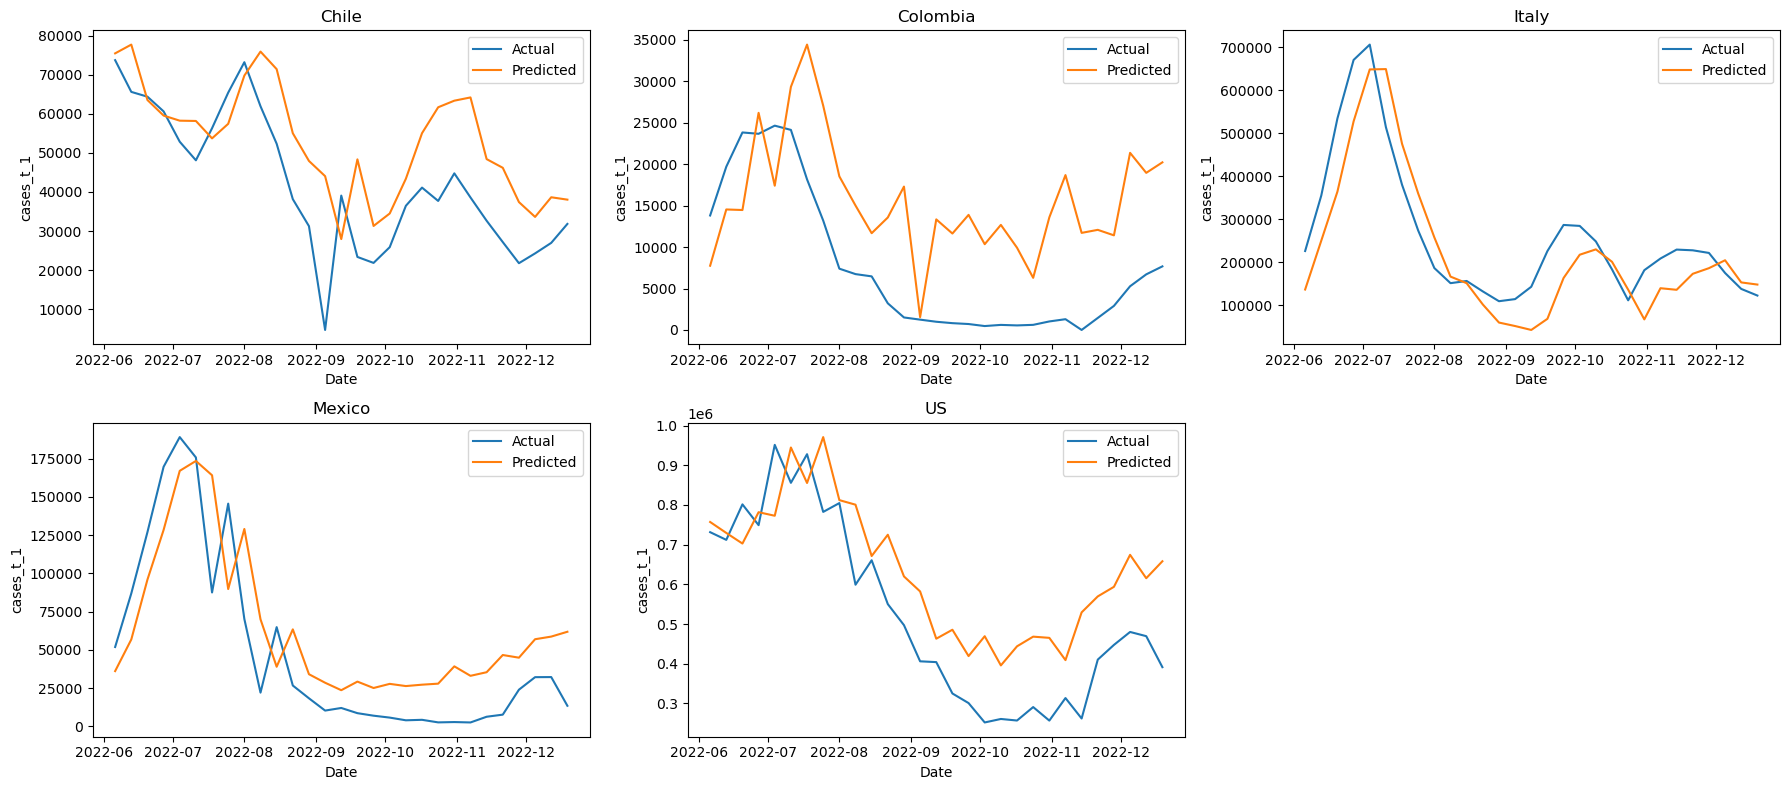

In [20]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for plotting
fit_records   = []   # date‑wise fitted values —> will pivot later

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1', 'date'])
    X = X.select_dtypes(include='number')

    # ---- 1.3  Chronological 80 / 20 split  ---------------------
    split_pt = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Fit Linear Regression
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)

    # ---- 1.5  Predict + metrics
    y_pred_test  = linreg.predict(X_test)
    y_pred_train = linreg.predict(X_train)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values for *all* rows (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table (unchanged)
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  ← NEW
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)          # long
      .pivot(index='date', columns='country', values='fitted')  # wide
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot section (unchanged)
# -------------------------------------------------------------
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

In [21]:
fitted_df.to_csv('../results/OLS_covid.csv', index = True)

## Lasso

In [22]:
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LassoCV
df = df_og.copy()


    country           rmse        r2       alpha
0     Chile   14022.953854  0.349622  153.019654
1  Colombia    9778.615906 -0.349907  157.087986
2     Italy   82906.066341  0.723005  227.108023
3    Mexico   31734.758409  0.696280  509.957859
4        US  172062.599774  0.405603  847.481646
country            Chile      Colombia          Italy        Mexico  \
date                                                                  
2020-03-23  23919.897818   6260.367281  112369.190735  30411.618915   
2020-03-30  19988.310646   9536.965381   50467.470502  21380.045273   
2020-04-06  10982.986962   6971.480229   28584.156402  14640.967631   
2020-04-13    -25.586311 -10240.969715    3794.938010    435.951264   
2020-04-20   -666.634653  -8659.248981   14269.083432   5634.388228   

country                US  
date                       
2020-03-23  381474.384350  
2020-03-30  366316.901496  
2020-04-06  272624.179339  
2020-04-13  217971.397108  
2020-04-20  229465.058306  


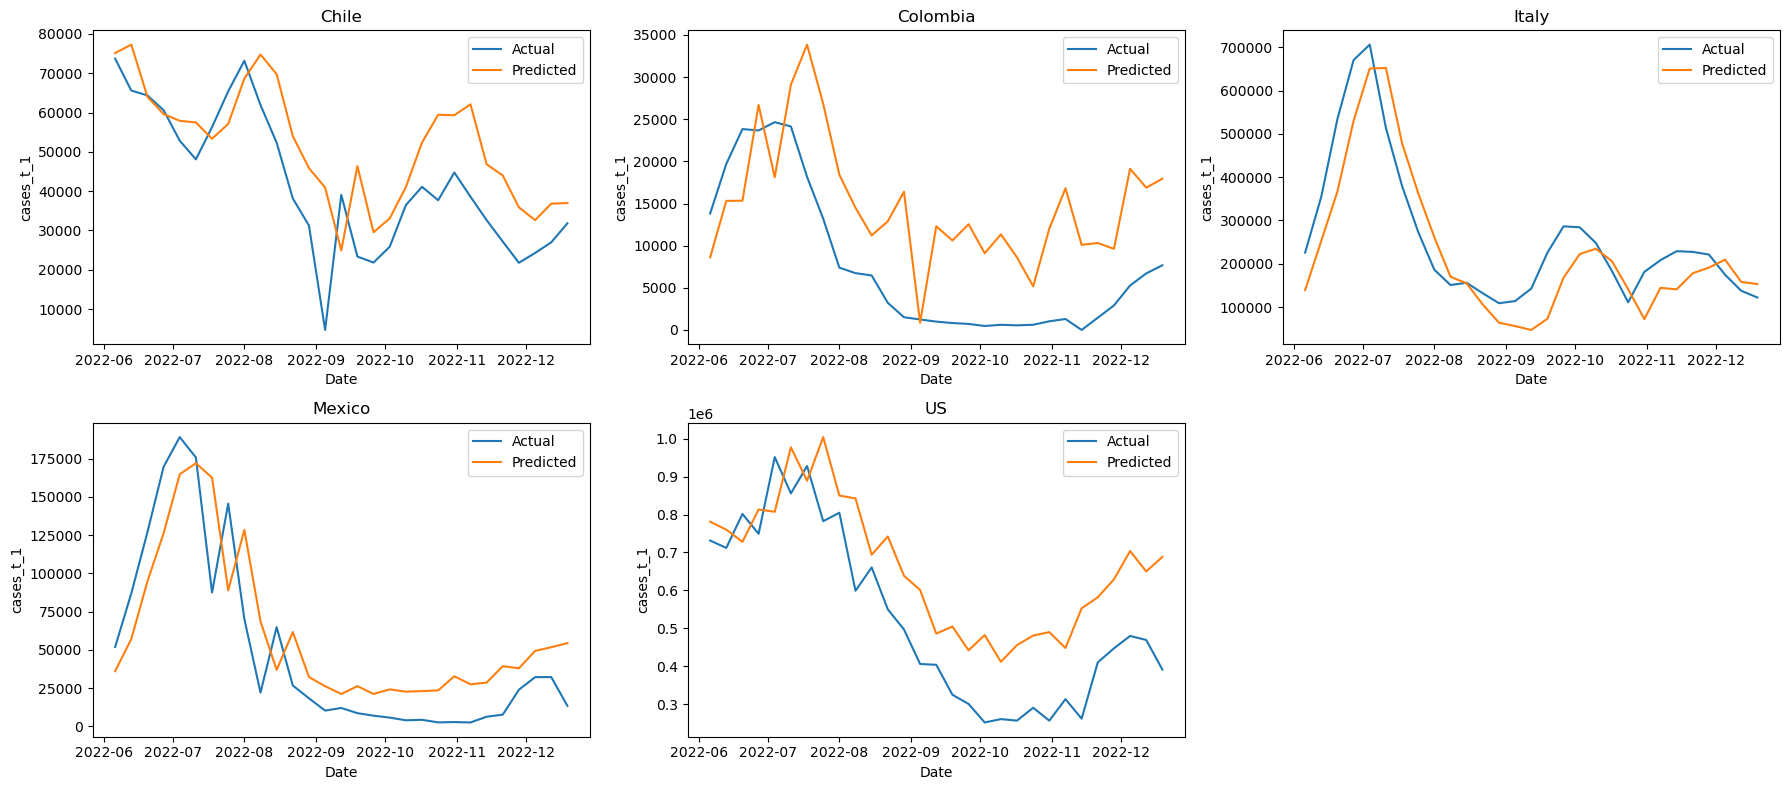

In [23]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1', 'date']).select_dtypes(include='number')

    # ---- 1.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: scaler → LassoCV
    #           inner CV keeps order (3 folds on TRAIN only)
    inner_cv = TimeSeriesSplit(n_splits=3)

    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LassoCV(cv=inner_cv,
                           random_state=42,
                           n_alphas=50,
                           max_iter=5000))
    ])

    lasso_pipe.fit(X_train, y_train)
    best_alpha = lasso_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = lasso_pipe.predict(X_test)
    y_pred_train = lasso_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)
    results.append({"country": country, "rmse": rmse, "r2": r2,
                    "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot Actual vs. Predicted (unchanged)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [24]:
# store results
fitted_df.to_csv('../results/Lasso_covid.csv', index = True)

## Ridge

In [25]:
from sklearn.linear_model  import RidgeCV
df = df_og.copy()

    country           rmse        r2     alpha
0     Chile   15399.940457  0.215623  0.001000
1  Colombia   10040.455531 -0.423167  0.788046
2     Italy   84563.604891  0.711819  0.045204
3    Mexico   33771.809135  0.656037  0.489390
4        US  153785.336774  0.525175  0.001000
country            Chile      Colombia          Italy        Mexico  \
date                                                                  
2020-03-23  21858.246899   5182.326857  115771.814159  29581.317883   
2020-03-30  19861.962635   9149.647078   53250.462382  17915.556480   
2020-04-06   9844.543523   6490.833773   31181.017206  10467.680209   
2020-04-13  -2032.587366 -11081.058490    6866.401893  -4821.357940   
2020-04-20  -3103.167491  -9290.761547   17413.258732   1236.240118   

country                US  
date                       
2020-03-23  399937.487751  
2020-03-30  383451.874301  
2020-04-06  289202.862964  
2020-04-13  232773.220840  
2020-04-20  244627.753650  


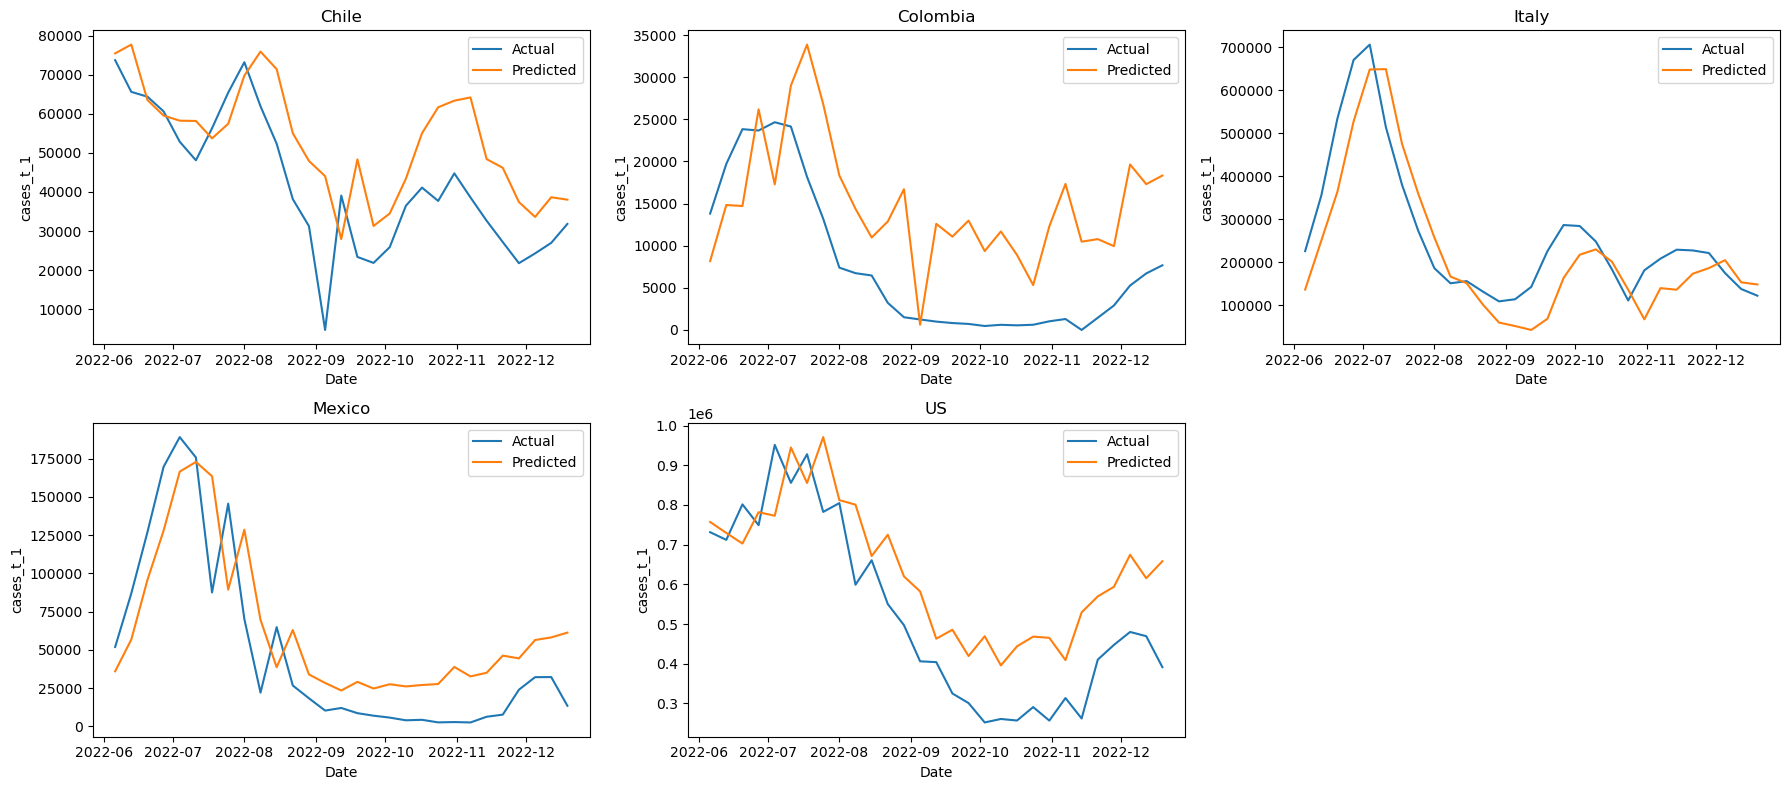

In [26]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c
         .drop(columns=['cases_t_1', 'date'])
         .select_dtypes(include='number'))

    # ---- 1.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler → RidgeCV
    inner_cv = TimeSeriesSplit(n_splits=3)   # CV folds on TRAIN only
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RidgeCV(alphas=np.logspace(-3, 3, 30),
                           cv=inner_cv,
                           scoring='neg_root_mean_squared_error'))
    ])

    ridge_pipe.fit(X_train, y_train)
    best_alpha = ridge_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = ridge_pipe.predict(X_test)
    y_pred_train = ridge_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2,
                    "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )
# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot Actual vs. Predicted (unchanged)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [27]:
# save the fitted values
fitted_df.to_csv('../results/Ridge_covid.csv', index = True)

## Elastic Net

In [28]:
from sklearn.linear_model  import ElasticNetCV
df = df_og.copy()

    country           rmse        r2     alpha
0     Chile   15343.749532  0.221336  0.001000
1  Colombia    9431.347071 -0.255731  0.028072
2     Italy   84400.402870  0.712930  0.001610
3    Mexico   33462.101877  0.662316  0.028072
4        US  155874.751938  0.512185  0.001000
country            Chile      Colombia          Italy        Mexico  \
date                                                                  
2020-03-23  21942.471042   5353.693389  115576.585764  30563.555588   
2020-03-30  19894.915259   9540.522473   53007.607910  18854.465756   
2020-04-06   9894.445018   6983.812792   30891.365332  11485.776775   
2020-04-13  -1973.216210 -10183.355978    6686.487916  -3708.576712   
2020-04-20  -3030.942725  -8190.850909   17269.777261   2055.938365   

country                US  
date                       
2020-03-23  398223.420634  
2020-03-30  381896.520870  
2020-04-06  287608.588928  
2020-04-13  231194.318518  
2020-04-20  243089.470262  


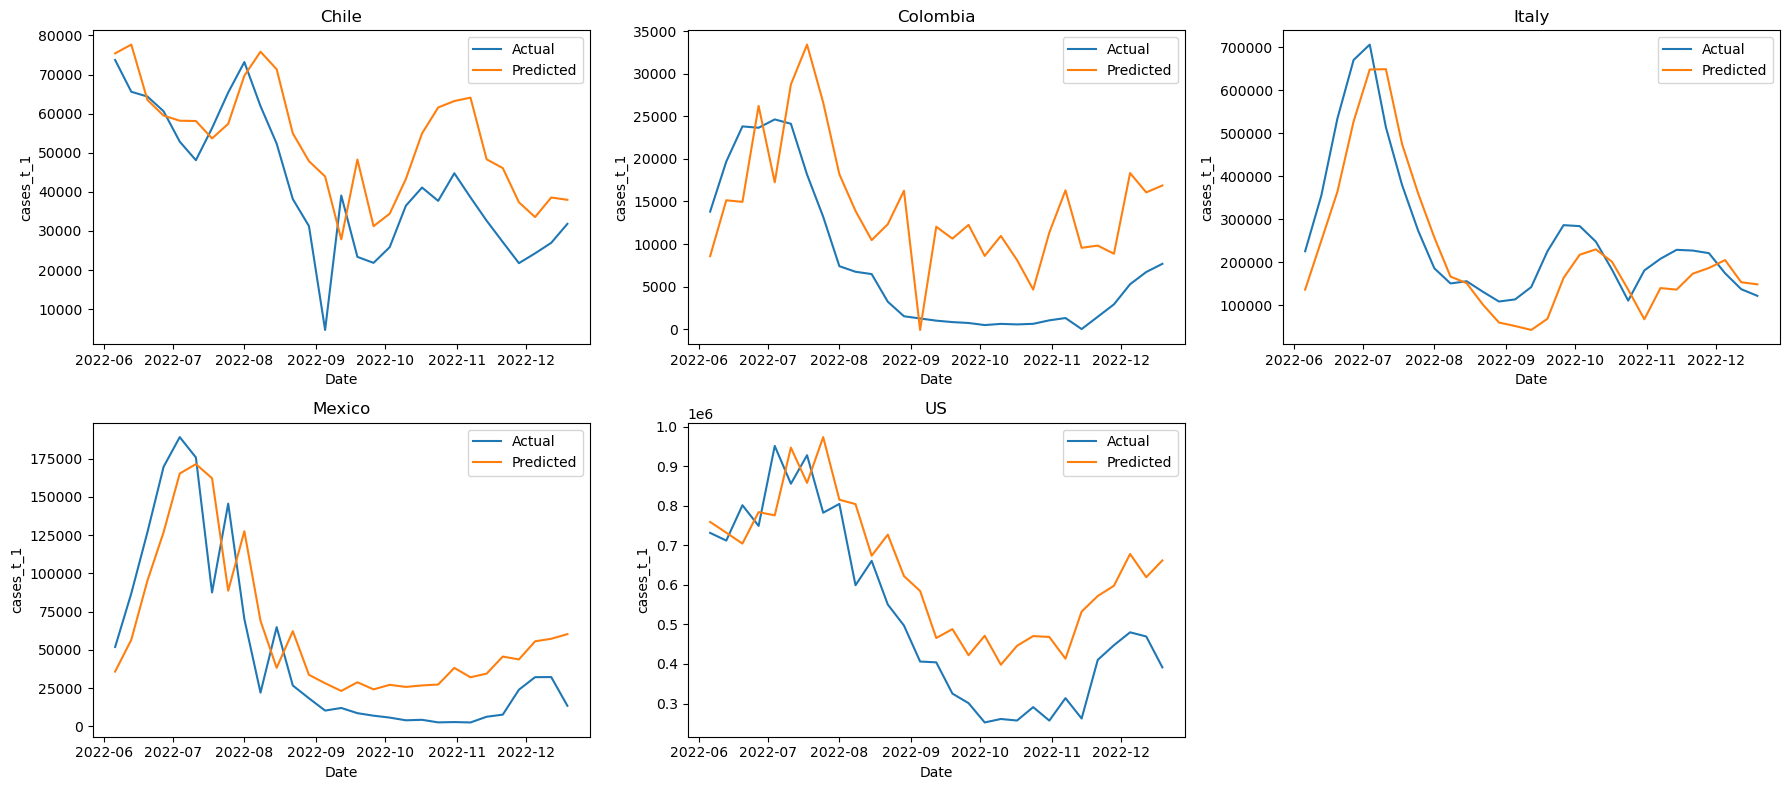

In [29]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    df_c = df_c.sort_values('date').reset_index(drop=True)

    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 1.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler → ElasticNetCV
    inner_cv = TimeSeriesSplit(n_splits=3)     # CV on TRAIN only
    enet_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  ElasticNetCV(
                      l1_ratio     = 0.5,
                      alphas       = np.logspace(-3, 3, 30),
                      cv           = inner_cv,
                      random_state = 42,
                      max_iter     = 5000))
    ])

    enet_pipe.fit(X_train, y_train)
    best_alpha = enet_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = enet_pipe.predict(X_test)
    y_pred_train = enet_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2,
                    "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [30]:
# save fitted values
fitted_df.to_csv('../results/ElasticNet_covid.csv', index = True)

## Random Forest

In [31]:
from sklearn.model_selection import  GridSearchCV
from sklearn.ensemble      import RandomForestRegressor
df = df_og.copy()

    country           rmse        r2  \
0     Chile   13895.023333  0.361435   
1  Colombia    5419.495174  0.585364   
2     Italy   92877.585522  0.652367   
3    Mexico   35789.922667  0.613700   
4        US  466596.868053 -3.371068   

                                         best_params  
0  {'bootstrap': True, 'max_depth': None, 'max_fe...  
1  {'bootstrap': False, 'max_depth': None, 'max_f...  
2  {'bootstrap': False, 'max_depth': None, 'max_f...  
3  {'bootstrap': False, 'max_depth': None, 'max_f...  
4  {'bootstrap': False, 'max_depth': None, 'max_f...  
country            Chile     Colombia    Italy       Mexico             US
date                                                                      
2020-03-23  24966.474287  1394.577236  31259.0  2246.441250  215112.073875
2020-03-30   5466.200487  1395.218903  27415.0  2276.515333  217015.606875
2020-04-06   5215.776862  1408.725569  22609.0  2276.515333  207796.237375
2020-04-13   4307.351567  1650.412514  18703.0  6426.0

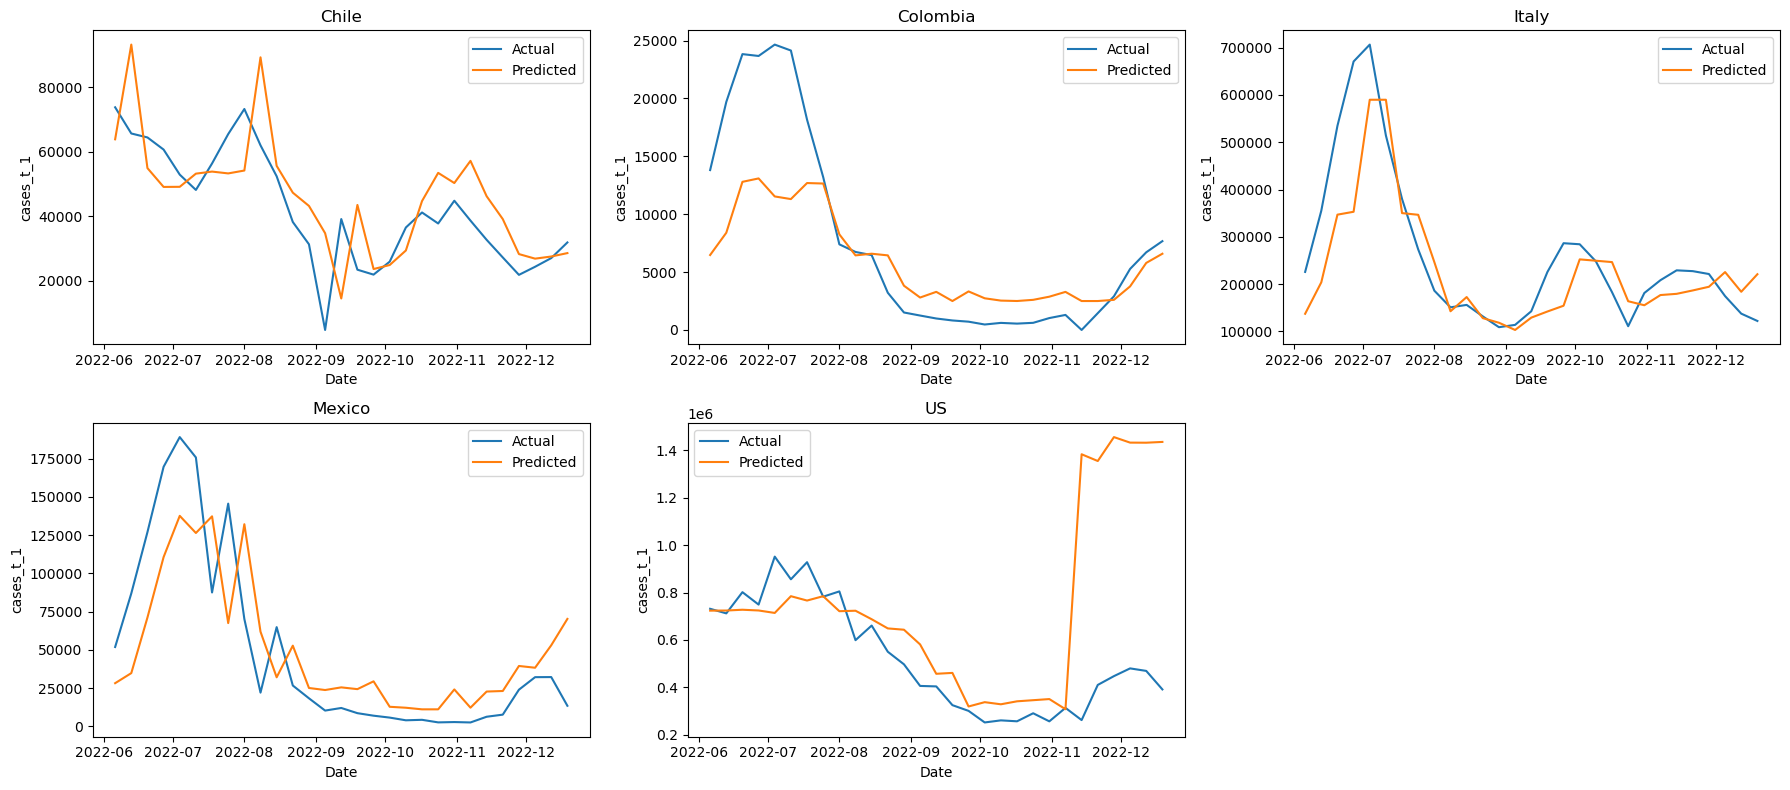

In [32]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid  (start coarse → tighten later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [400, 800, 1200],
    "max_depth":         [None, 10, 20],
    "max_features":      ["sqrt", 0.6, 0.8],
    "min_samples_leaf":  [1, 3, 5],
    "bootstrap":         [True, False]
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 2.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 2.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Inner CV: GridSearch over RF on TRAIN only ----
    inner_cv = TimeSeriesSplit(n_splits=3)
    rf_base  = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        estimator   = rf_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_rf     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_rf.predict(X_test)
    y_pred_train = best_rf.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [33]:
fitted_df.to_csv('../results/RF_covid.csv', index = True)

## Gradient Boosting

In [34]:
from sklearn.ensemble      import GradientBoostingRegressor
df = df_og.copy()

    country           rmse        r2  \
0     Chile   15783.953558  0.176017   
1  Colombia    3689.025162  0.807880   
2     Italy   74110.653872  0.778660   
3    Mexico   31247.901908  0.705527   
4        US  404409.996258 -2.283580   

                                         best_params  
0  {'learning_rate': 0.1, 'max_depth': 2, 'max_fe...  
1  {'learning_rate': 0.05, 'max_depth': 2, 'max_f...  
2  {'learning_rate': 0.1, 'max_depth': 2, 'max_fe...  
3  {'learning_rate': 0.03, 'max_depth': 3, 'max_f...  
4  {'learning_rate': 0.1, 'max_depth': 4, 'max_fe...  
country            Chile     Colombia         Italy       Mexico  \
date                                                               
2020-03-23  13168.566175  1122.524445  38967.413839  2193.793668   
2020-03-30   1410.151400  1010.983048  21476.993043  7018.127882   
2020-04-06   1486.648354  2166.268520  20912.181401  7190.793024   
2020-04-13   3788.617936  1108.163365  16186.058691  7997.569045   
2020-04-20   5382.768

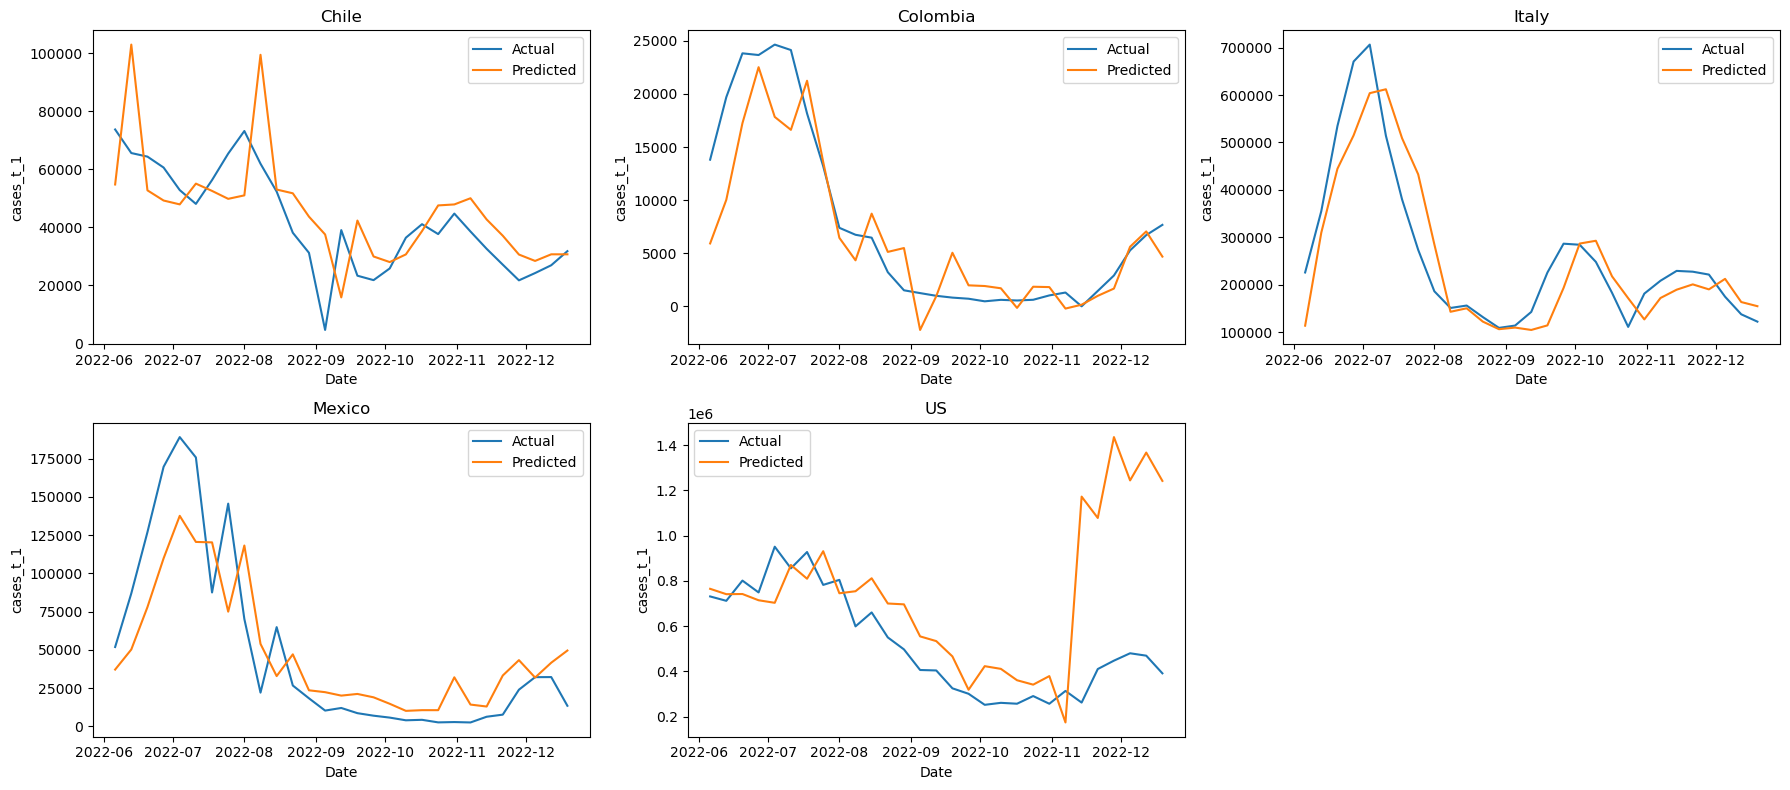

In [35]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for hold‑out plots
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid  (coarse → refine later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [200, 400, 800],
    "learning_rate":     [0.03, 0.05, 0.1],
    "max_depth":         [2, 3, 4],        # depth of individual trees
    "subsample":         [0.7, 0.9, 1.0],
    "min_samples_leaf":  [1, 3, 5],
    "max_features":      ["sqrt", 0.6, None]
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    df_c = df_c.sort_values('date').reset_index(drop=True)

    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 2.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Grid‑search GBM on training portion ------------
    inner_cv = TimeSeriesSplit(n_splits=3)     # folds inside TRAIN only
    gb_base  = GradientBoostingRegressor(random_state=42)

    grid = GridSearchCV(
        estimator  = gb_base,
        param_grid = param_grid,
        cv         = inner_cv,
        scoring    = "neg_root_mean_squared_error",
        n_jobs     = -1,
        verbose    = 0
    )
    grid.fit(X_train, y_train)
    best_gb     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics ------------------------------
    y_pred_test  = best_gb.predict(X_test)
    y_pred_train = best_gb.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test) -----------
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )


# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [36]:
fitted_df.to_csv('../results/GB_covid.csv', index = True)

## SVM

In [37]:

from sklearn.svm            import SVR
df = df_og.copy()


    country           rmse        r2  \
0     Chile   28150.567458 -1.620965   
1  Colombia   23141.461720 -6.560155   
2     Italy  243202.348079 -1.383606   
3    Mexico   58090.919110 -0.017701   
4        US  232404.550670 -0.084409   

                                         best_params  
0  {'model__C': 20, 'model__epsilon': 0.05, 'mode...  
1  {'model__C': 20, 'model__epsilon': 0.05, 'mode...  
2  {'model__C': 20, 'model__epsilon': 0.05, 'mode...  
3  {'model__C': 20, 'model__epsilon': 0.2, 'model...  
4  {'model__C': 20, 'model__epsilon': 0.05, 'mode...  
country            Chile      Colombia         Italy        Mexico  \
date                                                                 
2020-03-23  18546.603257  39437.361045  63266.725966  35844.285324   
2020-03-30  16391.463612  39941.722009  62672.514594  36460.452150   
2020-04-06  16088.049017  40240.542016  62126.075837  35956.276121   
2020-04-13  15577.410460  38219.410123  60480.925523  34717.048895   
2020-04-2

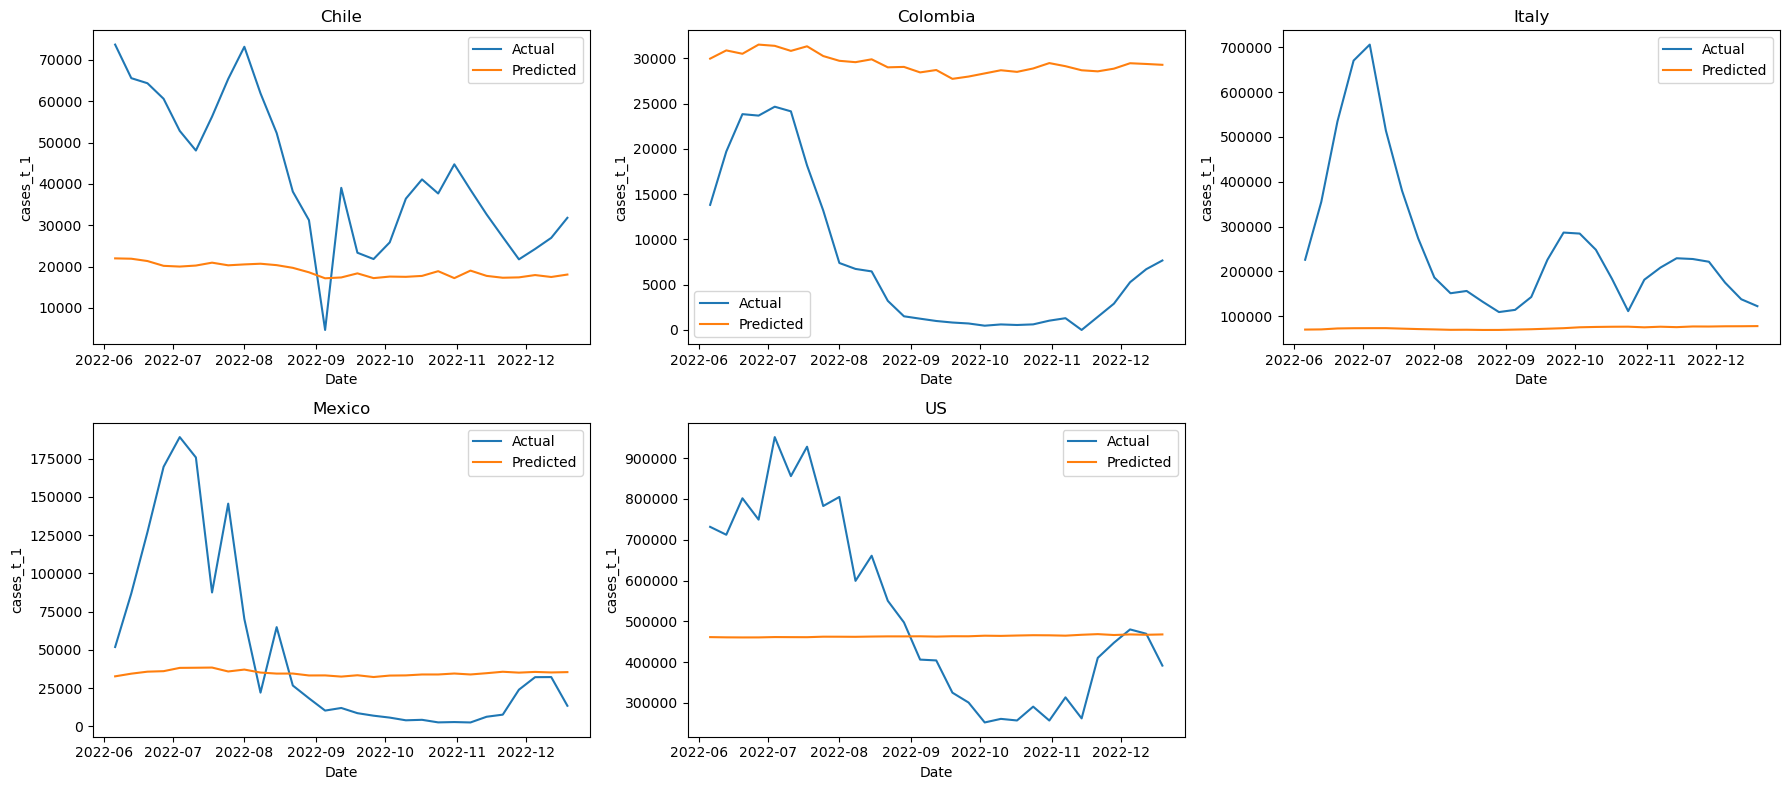

In [38]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid for SVR with an RBF kernel
#    (γ = 1 / (2σ²) in the RBF; tune together with C, ε)
# -------------------------------------------------------------
param_grid = [
    {   # RBF search
        "model__kernel":  ["rbf"],
        "model__C":       [0.5, 1, 5, 20],
        "model__epsilon": [0.05, 0.1, 0.2],
        "model__gamma":   ["scale", 0.01, 0.1, 1.0],
    },
    {   # Linear search (no gamma)
        "model__kernel":  ["linear"],
        "model__C":       [0.5, 1, 5, 20],
        "model__epsilon": [0.05, 0.1, 0.2],
    },
]

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 2.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 2.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Pipeline: StandardScaler → SVR -----------------
    inner_cv = TimeSeriesSplit(n_splits=3)     # CV folds on TRAIN only
    svr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  SVR())          # RBF to match the grid
    ])

    grid = GridSearchCV(
        estimator  = svr_pipe,
        param_grid = param_grid,
        cv         = inner_cv,
        scoring    = "neg_root_mean_squared_error",
        n_jobs     = -1,
        verbose    = 0
    )
    grid.fit(X_train, y_train)

    best_svr     = grid.best_estimator_
    best_params  = grid.best_params_

    # ---- 2.5  Predict + metrics ------------------------------
    y_pred_test  = best_svr.predict(X_test)
    y_pred_train = best_svr.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test) -----------
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )


# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [39]:
fitted_df.to_csv('../results/SVM_covid.csv', index = True)

# Coefficients

Make interpretable results, and check that the varnames and coefficients are ok

### Colombia

In [40]:
df = df_og.copy()

#### OLS

In [41]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for plotting
fit_records   = []   # date‑wise fitted values —> will pivot later

# -------------------------------------------------------------
# 1.  Filter Colombia
# -------------------------------------------------------------


country = 'Colombia'
df_c = df[df['country'] == country].copy()

# ---- 1.1  Chronological order
df_c = df_c.sort_values('date').reset_index(drop=True)

# ---- 1.2  Split features / target
y = df_c['cases_t_1']
X = df_c.drop(columns=['cases_t_1', 'date'])
X = X.select_dtypes(include='number')

# ---- 1.3  Chronological 80 / 20 split  ---------------------
split_pt = int(0.80 * len(df_c))          # oldest 80 % → train
train_idx = np.arange(split_pt)
test_idx  = np.arange(split_pt, len(df_c))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
dates_test      = df_c.loc[test_idx, 'date']

# ---- 1.4  Fit Linear Regression
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Get raw coefficients + intercept
β = linreg.coef_          # shape: (n_features,)
b = linreg.intercept_     # scalar

# Option A: as a NumPy array (intercept first)
all_coefs = np.concatenate([[b], β])
print("Coefficients (intercept first):", all_coefs)

# Option B: as a pandas Series with names
feature_names = X_train.columns.tolist()
coef_series = pd.Series(
    data=np.concatenate([[b], β]),
    index=["intercept"] + feature_names
)
coef_series

Coefficients (intercept first): [-1.96452346e+06  7.34671074e-01  2.68198371e+03 -2.17414213e+03
 -7.49122987e+02  8.44534724e+02  3.34547438e+02  1.17255473e-03]


intercept                 -1.964523e+06
new_cases                  7.346711e-01
google_symptom             2.681984e+03
o3                        -2.174142e+03
pop_vaccinated            -7.491230e+02
no2                        8.445347e+02
StringencyIndex_Average    3.345474e+02
date_numeric               1.172555e-03
dtype: float64

In [42]:
X_train.columns

Index(['new_cases', 'google_symptom', 'o3', 'pop_vaccinated', 'no2',
       'StringencyIndex_Average', 'date_numeric'],
      dtype='object')

In [43]:
import statsmodels.api as sm

# 1. Add a constant column for the intercept
X_train_const = sm.add_constant(X_train)  # adds a “const” column of 1s

# 2. Fit the OLS on your training data
ols_sm = sm.OLS(y_train, X_train_const).fit()

# 3. Print the full regression table
print(ols_sm.summary())

                            OLS Regression Results                            
Dep. Variable:              cases_t_1   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     289.7
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           1.71e-66
Time:                        21:20:30   Log-Likelihood:                -1244.2
No. Observations:                 115   AIC:                             2504.
Df Residuals:                     107   BIC:                             2526.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                   -1

In [44]:

# 1. Build a DataFrame of the stats you care about
results_df = pd.DataFrame({
    
    "p_val"  : ols_sm.pvalues
})

# 2. (Optional) Round to 4 decimals or however many you like
results_df = results_df.round(4)

# 3. Export to LaTeX
latex_table = results_df.to_latex(
    caption="OLS parameter estimates",
    label="tab:ols_pvalues_covid",
    float_format="%.4f"
)
print(latex_table)

\begin{table}
\caption{OLS parameter estimates}
\label{tab:ols_pvalues_covid}
\begin{tabular}{lr}
\toprule
 & p_val \\
\midrule
const & 0.0000 \\
new_cases & 0.0000 \\
google_symptom & 0.0000 \\
o3 & 0.0021 \\
pop_vaccinated & 0.0000 \\
no2 & 0.3208 \\
StringencyIndex_Average & 0.0313 \\
date_numeric & 0.0000 \\
\bottomrule
\end{tabular}
\end{table}



#### Lasso

In [45]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for plotting
fit_records   = []   # date‑wise fitted values —> will pivot later

# -------------------------------------------------------------
# 1.  Filter Colombia
# -------------------------------------------------------------


country = 'Colombia'
df_c = df[df['country'] == country].copy()



# ---- 1.1  Chronological order
df_c = df_c.sort_values('date').reset_index(drop=True)

# ---- 1.2  Split features / target
y = df_c['cases_t_1']
X = df_c.drop(columns=['cases_t_1', 'date']).select_dtypes(include='number')

# ---- 1.3  Chronological 80 / 20 split --------------------
split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
train_idx = np.arange(split_pt)
test_idx  = np.arange(split_pt, len(df_c))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
dates_test      = df_c.loc[test_idx, 'date']

# ---- 1.4  Pipeline: scaler → LassoCV
#           inner CV keeps order (3 folds on TRAIN only)
inner_cv = TimeSeriesSplit(n_splits=3)

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LassoCV(cv=inner_cv,
                        random_state=42,
                        n_alphas=50,
                        max_iter=5000))
])


lasso_pipe.fit(X_train, y_train)

# Extract scaled‐space coefs + intercept
beta_lasso      = lasso_pipe.named_steps["model"].coef_       # shape (n_features,)
intercept_lasso = lasso_pipe.named_steps["model"].intercept_  # scalar

# NumPy array (intercept first)
coefs_with_intercept_lasso = np.concatenate([[intercept_lasso], beta_lasso])
print("Coefficients (intercept first):", coefs_with_intercept_lasso)

# 3B. pandas Series with names
feature_names = X_train.columns.tolist()
coefs_series_lasso = pd.Series(
    data=coefs_with_intercept_lasso,
    index=["intercept"] + feature_names
)
coefs_series_lasso

Coefficients (intercept first): [ 53192.56521739  40530.10394642  15589.55138282  -4664.8156448
 -17115.68707685   1548.68129643   4762.28471091  19607.84215256]


intercept                  53192.565217
new_cases                  40530.103946
google_symptom             15589.551383
o3                         -4664.815645
pop_vaccinated            -17115.687077
no2                         1548.681296
StringencyIndex_Average     4762.284711
date_numeric               19607.842153
dtype: float64

In [46]:
# 1. Extract scaler and fitted LassoCV model
scaler_lasso = lasso_pipe.named_steps["scaler"]
model_lasso  = lasso_pipe.named_steps["model"]

# 2. Get the scaled‐space coefficients + intercept
beta_scaled_lasso       = model_lasso.coef_        # shape: (n_features,)
intercept_scaled_lasso  = model_lasso.intercept_   # scalar

# 3. Grab scaler parameters
means_lasso  = scaler_lasso.mean_   # shape: (n_features,)
scales_lasso = scaler_lasso.scale_  # shape: (n_features,)

# 4. Un-scale the feature coefficients
beta_orig_lasso = beta_scaled_lasso / scales_lasso

# 5. Compute the original-scale intercept
intercept_orig_lasso = (
    intercept_scaled_lasso
    - np.dot(beta_scaled_lasso, means_lasso / scales_lasso)
)

# 6A. As a NumPy array (intercept first)
coefs_with_intercept_lasso_orig = np.concatenate(
    [[intercept_orig_lasso], beta_orig_lasso]
)
print("Lasso (original scale) – intercept first:", coefs_with_intercept_lasso_orig)

# 6B. As a pandas Series with named index
feature_names = X_train.columns.tolist()
coefs_series_lasso_orig = pd.Series(
    data=coefs_with_intercept_lasso_orig,
    index=["intercept"] + feature_names,
    name="lasso_orig_scale"
)
coefs_series_lasso_orig

Lasso (original scale) – intercept first: [-1.64089666e+06  7.49704244e-01  2.55879175e+03 -2.15593886e+03
 -6.55303128e+02  7.99526843e+02  2.52420392e+02  9.76623617e-04]


intercept                 -1.640897e+06
new_cases                  7.497042e-01
google_symptom             2.558792e+03
o3                        -2.155939e+03
pop_vaccinated            -6.553031e+02
no2                        7.995268e+02
StringencyIndex_Average    2.524204e+02
date_numeric               9.766236e-04
Name: lasso_orig_scale, dtype: float64

#### Ridge

In [47]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])


# -------------------------------------------------------------
# 1.  Filter Colombia
# -------------------------------------------------------------


country = 'Colombia'
df_c = df[df['country'] == country].copy()

# ---- 1.1  Chronological order
df_c = df_c.sort_values('date').reset_index(drop=True)

# ---- 1.2  Split features / target
y = df_c['cases_t_1']
X = (df_c
        .drop(columns=['cases_t_1', 'date'])
        .select_dtypes(include='number'))

# ---- 1.3  Chronological 80 / 20 split --------------------
split_pt  = int(0.80 * len(df_c))
train_idx = np.arange(split_pt)
test_idx  = np.arange(split_pt, len(df_c))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
dates_test      = df_c.loc[test_idx, 'date']

# ---- 1.4  Pipeline: StandardScaler → RidgeCV
inner_cv = TimeSeriesSplit(n_splits=3)   # CV folds on TRAIN only
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RidgeCV(alphas=np.logspace(-3, 3, 30),
                        cv=inner_cv,
                        scoring='neg_root_mean_squared_error'))
])

ridge_pipe.fit(X_train, y_train)
best_alpha = ridge_pipe.named_steps["model"].alpha_

# Extract scaled‐space coefs + intercept
beta_ridge      = ridge_pipe.named_steps["model"].coef_       # shape (n_features,)
intercept_ridge = ridge_pipe.named_steps["model"].intercept_  # scalar

# NumPy array (intercept first)
coefs_with_intercept_ridge = np.concatenate([[intercept_ridge], beta_ridge])
print("Coefficients (intercept first):", coefs_with_intercept_ridge)

# 3B. pandas Series with names
feature_names = X_train.columns.tolist()
coefs_series_ridge = pd.Series(
    data=coefs_with_intercept_ridge,
    index=["intercept"] + feature_names
)

Coefficients (intercept first): [ 53192.56521739  40050.93148182  15953.10064809  -4878.47649814
 -17703.84571857   1721.07311379   5677.91650913  20875.51162173]


In [48]:
# 1. Extract scaler and fitted RidgeCV model
scaler_ridge = ridge_pipe.named_steps["scaler"]
model_ridge  = ridge_pipe.named_steps["model"]

# 2. Get the scaled-space coefficients + intercept
beta_scaled_ridge      = model_ridge.coef_        # shape: (n_features,)
intercept_scaled_ridge = model_ridge.intercept_   # scalar

# 3. Grab scaler parameters
means_ridge  = scaler_ridge.mean_    # shape: (n_features,)
scales_ridge = scaler_ridge.scale_   # shape: (n_features,)

# 4. Un-scale the feature coefficients
beta_orig_ridge = beta_scaled_ridge / scales_ridge

# 5. Compute the original-scale intercept
intercept_orig_ridge = (
    intercept_scaled_ridge
    - np.dot(beta_scaled_ridge, means_ridge / scales_ridge)
)

# 6A. As a NumPy array (intercept first)
coefs_with_intercept_ridge_orig = np.concatenate(
    [[intercept_orig_ridge], beta_orig_ridge]
)
print("Ridge (original scale) – intercept first:", coefs_with_intercept_ridge_orig)

# 6B. As a pandas Series with named index
feature_names = X_train.columns.tolist()
coefs_series_ridge_orig = pd.Series(
    data=coefs_with_intercept_ridge_orig,
    index=["intercept"] + feature_names,
    name="ridge_orig_scale"
)
coefs_series_ridge_orig

Ridge (original scale) – intercept first: [-1.74730763e+06  7.40840767e-01  2.61846293e+03 -2.25468654e+03
 -6.77821780e+02  8.88526358e+02  3.00952589e+02  1.03976345e-03]


intercept                 -1.747308e+06
new_cases                  7.408408e-01
google_symptom             2.618463e+03
o3                        -2.254687e+03
pop_vaccinated            -6.778218e+02
no2                        8.885264e+02
StringencyIndex_Average    3.009526e+02
date_numeric               1.039763e-03
Name: ridge_orig_scale, dtype: float64

#### Elastic Net

In [49]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])


# -------------------------------------------------------------
# 1.  Filter Colombia
# -------------------------------------------------------------

country = 'Colombia'
df_c = df[df['country'] == country].copy()

df_c = df_c.sort_values('date').reset_index(drop=True)

y = df_c['cases_t_1']
X = (df_c.drop(columns=['cases_t_1', 'date'])
            .select_dtypes(include='number'))

# ---- 1.3  Chronological 80 / 20 split --------------------
split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
train_idx = np.arange(split_pt)
test_idx  = np.arange(split_pt, len(df_c))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
dates_test      = df_c.loc[test_idx, 'date']

# ---- 1.4  Pipeline: StandardScaler → ElasticNetCV
inner_cv = TimeSeriesSplit(n_splits=3)     # CV on TRAIN only
enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  ElasticNetCV(
                    l1_ratio     = 0.5,
                    alphas       = np.logspace(-3, 3, 30),
                    cv           = inner_cv,
                    random_state = 42,
                    max_iter     = 5000))
])

enet_pipe.fit(X_train, y_train)

# 2. Extract scaled-space coefs + intercept
beta_enet      = enet_pipe.named_steps["model"].coef_       # shape (n_features,)
intercept_enet = enet_pipe.named_steps["model"].intercept_  # scalar

# 3A. NumPy array (intercept first)
coefs_with_intercept_enet = np.concatenate([[intercept_enet], beta_enet])
print("ElasticNet coefficients (intercept first):", coefs_with_intercept_enet)

# 3B. pandas Series with named index
feature_names = X_train.columns.tolist()
coefs_series_enet = pd.Series(
    data=coefs_with_intercept_enet,
    index=["intercept"] + feature_names
)
coefs_series_enet


ElasticNet coefficients (intercept first): [ 53192.56521739  40236.99676312  15638.26535915  -5030.39921938
 -16231.14962801   1759.82542954   5171.12073717  18761.13419915]


intercept                  53192.565217
new_cases                  40236.996763
google_symptom             15638.265359
o3                         -5030.399219
pop_vaccinated            -16231.149628
no2                         1759.825430
StringencyIndex_Average     5171.120737
date_numeric               18761.134199
dtype: float64

In [50]:
# 1. Extract scaler and fitted ElasticNetCV model
scaler_enet = enet_pipe.named_steps["scaler"]
model_enet  = enet_pipe.named_steps["model"]

# 2. Get the scaled-space coefficients + intercept
beta_scaled_enet      = model_enet.coef_        # shape: (n_features,)
intercept_scaled_enet = model_enet.intercept_   # scalar

# 3. Grab scaler parameters
means_enet  = scaler_enet.mean_    # shape: (n_features,)
scales_enet = scaler_enet.scale_   # shape: (n_features,)

# 4. Un-scale the feature coefficients
beta_orig_enet = beta_scaled_enet / scales_enet

# 5. Compute the original-scale intercept
intercept_orig_enet = (
    intercept_scaled_enet
    - np.dot(beta_scaled_enet, means_enet / scales_enet)
)

# 6A. As a NumPy array (intercept first)
coefs_with_intercept_enet_orig = np.concatenate(
    [[intercept_orig_enet], beta_orig_enet]
)
print("ElasticNet (original scale) – intercept first:", coefs_with_intercept_enet_orig)

# 6B. As a pandas Series with named index
feature_names = X_train.columns.tolist()
coefs_series_enet_orig = pd.Series(
    data=coefs_with_intercept_enet_orig,
    index=["intercept"] + feature_names,
    name="elasticnet_orig_scale"
)
print(coefs_series_enet_orig)

ElasticNet (original scale) – intercept first: [-1.57472169e+06  7.44282504e-01  2.56678742e+03 -2.32490070e+03
 -6.21437111e+02  9.08532745e+02  2.74090359e+02  9.34450951e-04]
intercept                 -1.574722e+06
new_cases                  7.442825e-01
google_symptom             2.566787e+03
o3                        -2.324901e+03
pop_vaccinated            -6.214371e+02
no2                        9.085327e+02
StringencyIndex_Average    2.740904e+02
date_numeric               9.344510e-04
Name: elasticnet_orig_scale, dtype: float64


#### All coefficients

See the coefficients to have varnames

In [51]:
# make a table with coefficients
coef_table = pd.DataFrame({
    "LinearRegression": coef_series,
    "Lasso":     coefs_series_lasso_orig,
    "Ridge":     coefs_series_ridge_orig,
    "ElasticNet": coefs_series_enet_orig
}).T
coef_table

,intercept,new_cases,google_symptom,o3,pop_vaccinated,no2,StringencyIndex_Average,date_numeric
LinearRegression,-1.964523e+06,0.734671,2681.983706,-2174.142133,-749.122987,844.534724,334.547438,0.001173
Lasso,-1.640897e+06,0.749704,2558.791752,-2155.938862,-655.303128,799.526843,252.420392,0.000977
Ridge,-1.747308e+06,0.740841,2618.462927,-2254.686545,-677.821780,888.526358,300.952589,0.001040
ElasticNet,-1.574722e+06,0.744283,2566.787422,-2324.900702,-621.437111,908.532745,274.090359,0.000934


In [52]:

latex_code = coef_table.to_latex(
    float_format="%.2f",
    caption="Model coefficients (original scale)",
    label="tab:coef_table"
)
print(latex_code)

\begin{table}
\caption{Model coefficients (original scale)}
\label{tab:coef_table}
\begin{tabular}{lrrrrrrrr}
\toprule
 & intercept & new_cases & google_symptom & o3 & pop_vaccinated & no2 & StringencyIndex_Average & date_numeric \\
\midrule
LinearRegression & -1964523.46 & 0.73 & 2681.98 & -2174.14 & -749.12 & 844.53 & 334.55 & 0.00 \\
Lasso & -1640896.66 & 0.75 & 2558.79 & -2155.94 & -655.30 & 799.53 & 252.42 & 0.00 \\
Ridge & -1747307.63 & 0.74 & 2618.46 & -2254.69 & -677.82 & 888.53 & 300.95 & 0.00 \\
ElasticNet & -1574721.69 & 0.74 & 2566.79 & -2324.90 & -621.44 & 908.53 & 274.09 & 0.00 \\
\bottomrule
\end{tabular}
\end{table}



# Feature Importance

## RF

In [53]:
df = df_og.copy()

Test RMSE: 5419.495173843169
Test R²: 0.5853641774809183


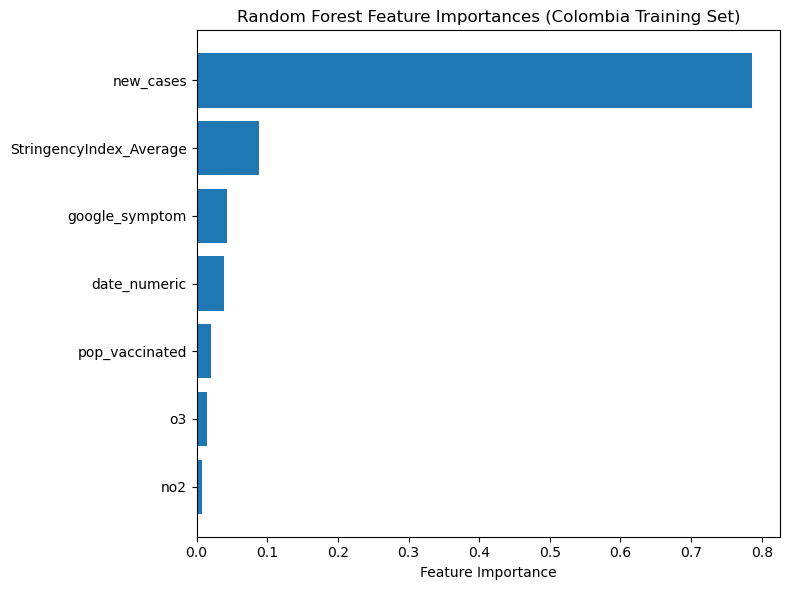

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

# -------------------------------------------------------------
# 1.  Filter to Colombia and sort
# -------------------------------------------------------------
df_c = (
    df[df['country'] == 'Colombia']
    .sort_values('date')
    .reset_index(drop=True)
)

# -------------------------------------------------------------
# 2.  Split features / target
# -------------------------------------------------------------
y = df_c['cases_t_1']
X = (
    df_c
    .drop(columns=['country','cases_t_1','date'])
    .select_dtypes(include='number')
)

# -------------------------------------------------------------
# 3.  Chronological 80 / 20 split
# -------------------------------------------------------------
split_pt   = int(0.8 * len(X))
X_train    = X.iloc[:split_pt]
X_test     = X.iloc[split_pt:]
y_train    = y.iloc[:split_pt]
y_test     = y.iloc[split_pt:]

# -------------------------------------------------------------
# 4.  GridSearchCV on RandomForest (inner time‑series CV)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":     [400, 800, 1200],
    "max_depth":        [None, 10, 20],
    "max_features":     ["sqrt", 0.6, 0.8],
    "min_samples_leaf": [1, 3, 5],
    "bootstrap":        [True, False]
}
ts_cv = TimeSeriesSplit(n_splits=3)
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator   = rf_base,
    param_grid  = param_grid,
    cv          = ts_cv,
    scoring     = "neg_root_mean_squared_error",
    n_jobs      = -1
)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

# -------------------------------------------------------------
# 5.  Compute performance on test (optional)
# -------------------------------------------------------------
y_pred = best_rf.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R²:", r2_score(y_test, y_pred))

# -------------------------------------------------------------
# 6.  Extract & plot feature importances (training)
# -------------------------------------------------------------
importances     = best_rf.feature_importances_
feature_names   = X_train.columns

# sort for nicer plotting
idx_sorted = np.argsort(importances)
plt.figure(figsize=(8, 6))
plt.barh(feature_names[idx_sorted], importances[idx_sorted])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (Colombia Training Set)")
plt.tight_layout()
plt.show()


## GB

Test RMSE: 3689.025162498432
Test R²: 0.8078800842152478


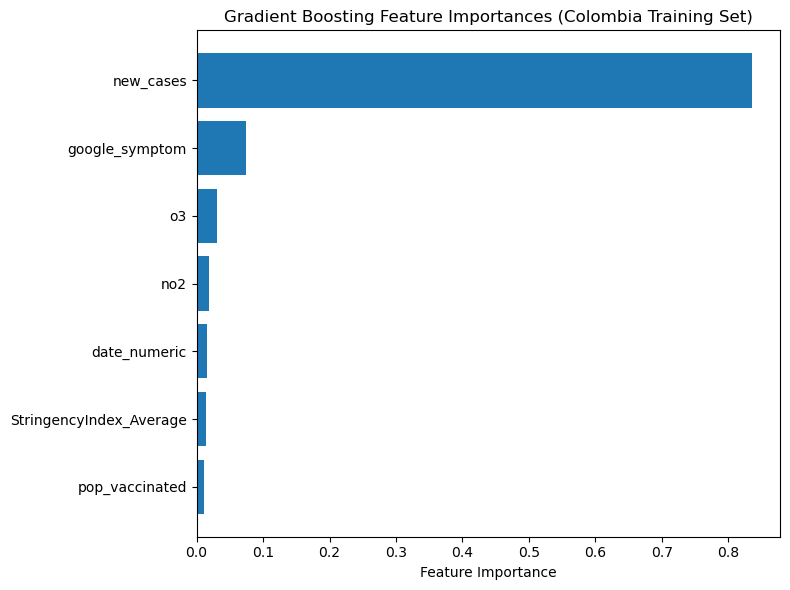

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

# -------------------------------------------------------------
# 1.  Filter to Colombia and sort by date
# -------------------------------------------------------------
df_c = (
    df[df['country'] == 'Colombia']
    .sort_values('date')
    .reset_index(drop=True)
)

# -------------------------------------------------------------
# 2.  Split features / target
# -------------------------------------------------------------
y = df_c['cases_t_1']
X = (
    df_c
    .drop(columns=['country', 'cases_t_1', 'date'])
    .select_dtypes(include='number')
)

# -------------------------------------------------------------
# 3.  Chronological 80 / 20 train‑test split
# -------------------------------------------------------------
split_pt = int(0.8 * len(X))
X_train, X_test = X.iloc[:split_pt], X.iloc[split_pt:]
y_train, y_test = y.iloc[:split_pt], y.iloc[split_pt:]

# -------------------------------------------------------------
# 4.  GridSearchCV over GradientBoostingRegressor
# -------------------------------------------------------------
param_grid = {
    "n_estimators":     [200, 400, 800],
    "learning_rate":    [0.03, 0.05, 0.1],
    "max_depth":        [2, 3, 4],
    "subsample":        [0.7, 0.9, 1.0],
    "min_samples_leaf": [1, 3, 5],
    "max_features":     ["sqrt", 0.6, None]
}
ts_cv = TimeSeriesSplit(n_splits=3)
gb_base = GradientBoostingRegressor(random_state=42)

grid = GridSearchCV(
    estimator   = gb_base,
    param_grid  = param_grid,
    cv          = ts_cv,
    scoring     = "neg_root_mean_squared_error",
    n_jobs      = -1
)
grid.fit(X_train, y_train)
best_gb = grid.best_estimator_

# -------------------------------------------------------------
# 5.  (Optional) Evaluate on test set
# -------------------------------------------------------------
y_pred = best_gb.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R²:", r2_score(y_test, y_pred))

# -------------------------------------------------------------
# 6.  Extract & plot feature importances (training)
# -------------------------------------------------------------
importances   = best_gb.feature_importances_
feat_names    = X_train.columns
idx_sorted    = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(feat_names[idx_sorted], importances[idx_sorted])
plt.xlabel("Feature Importance")
plt.title("Gradient Boosting Feature Importances (Colombia Training Set)")
plt.tight_layout()
plt.show()


## Combined Plot

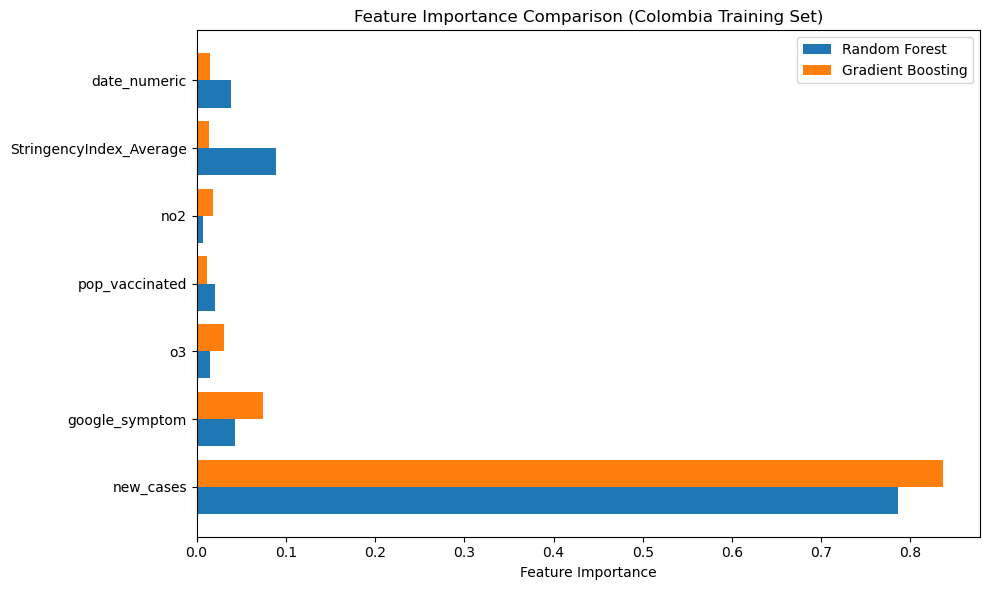

In [56]:
# Extract importances and feature names
importances_rf = best_rf.feature_importances_
importances_gb = best_gb.feature_importances_
feat_names     = X_train.columns.tolist()

# Prepare positions for grouped bars
y_pos = np.arange(len(feat_names))
height = 0.4

fig, ax = plt.subplots(figsize=(10, 6))

# Plot grouped horizontal bars
ax.barh(y_pos - height/2, importances_rf, height=height, label="Random Forest")
ax.barh(y_pos + height/2, importances_gb, height=height, label="Gradient Boosting")

# Labeling
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_names)
ax.set_xlabel("Feature Importance")
ax.set_title("Feature Importance Comparison (Colombia Training Set)")
ax.legend()

plt.tight_layout()
# save to pdf
plt.savefig('../latex_plots/feature_importance_covid.pdf', bbox_inches='tight')
plt.show()
